In [98]:
from src import *

import numpy as np
import matplotlib.pyplot as plt
import os

from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [99]:
plt.rcdefaults()

from matplotlib_inline import backend_inline
backend_inline.set_matplotlib_formats('svg')
del backend_inline

from matplotlib.font_manager import fontManager
fontManager.addfont('src/lmroman10.otf')
del fontManager

plt.rcParams['font.family'] = 'Latin Modern Roman'
plt.rcParams['mathtext.fontset'] = 'cm'

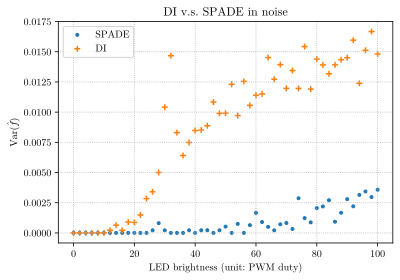

In [100]:
di_pn = LoadEstimates(f'__estimates__/noisy/di_5px/di_5px_f0.2_d0.npz').photons.mean()
spade_pn = LoadEstimates(f'__estimates__/noisy/spade_5px/spade_5px_f0.2_d0.npz').photons.mean()

di_x, spade_x = [], []
di_y, spade_y = [], []
plt.figure(figsize=(6, 4))

for duty in np.arange(0, 101, 2):
    for m in ('spade', 'di'):
        c = LoadEstimates(f'__estimates__/noisy/{m}_5px/{m}_5px_f0.2_d{duty}.npz')
        if m == 'spade':
            spade_x.append(duty)
            spade_y.append(c.frequency_estimates.var(ddof=1) * 1)

        if m == 'di':
            di_x.append(duty)
            di_y.append(c.frequency_estimates.var(ddof=1) * 1)


plt.scatter(spade_x, spade_y, marker='.', label='SPADE')
plt.scatter(di_x, di_y, marker='+', label='DI')


plt.legend()
plt.grid(True, linestyle=':')


plt.xlabel('LED brightness (unit: PWM duty)')
plt.ylabel(r'${\rm Var}(\hat f)$')
plt.title('DI v.s. SPADE in noise')
plt.show()

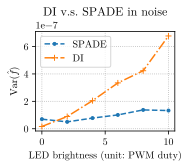

In [101]:
di_pn = LoadEstimates(f'__estimates__/noisy/di_5px/di_5px_f0.2_d0.npz').photons.mean()
spade_pn = LoadEstimates(f'__estimates__/noisy/spade_5px/spade_5px_f0.2_d0.npz').photons.mean()

di_x, spade_x = [], []
di_y, spade_y = [], []
plt.figure(figsize=(2.5, 1.8))

for duty in np.arange(0, 11, 2):
    for m in ('spade', 'di'):
        c = LoadEstimates(f'__estimates__/noisy/{m}_5px/{m}_5px_f0.2_d{duty}.npz')
        if m == 'spade':
            spade_x.append(duty)
            spade_y.append(c.frequency_estimates.var(ddof=1) * 1)

        if m == 'di':
            di_x.append(duty)
            di_y.append(c.frequency_estimates.var(ddof=1) * 1)


plt.plot(spade_x, spade_y, '.--', label='SPADE')
plt.plot(di_x, di_y, '+-.', label='DI')


plt.legend()
plt.grid(True, linestyle=':')


plt.xlabel('LED brightness (unit: PWM duty)')
plt.ylabel(r'${\rm Var}(\hat f)$')
plt.title('DI v.s. SPADE in noise')
plt.show()

In [110]:
di_x, spade_x = [], []
di_y, spade_y = [], []

for duty in np.arange(0, 101, 2):
    for m in ('spade', 'di'):
        c = LoadEstimates(f'__estimates__/noisy/{m}_5px/{m}_5px_f0.2_d{duty}.npz')
        if m == 'spade':
            spade_x.append(duty)
            spade_y.append(c.frequency_estimates.var(ddof=1) * 1)

        if m == 'di':
            di_x.append(duty)
            di_y.append(c.frequency_estimates.var(ddof=1) * 1)

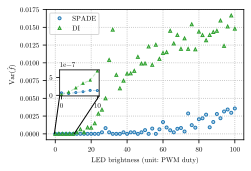

In [180]:
size = 9

plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'

fig, ax = plt.subplots(1, 1, figsize=(size / 2.54, size / 2.54 / 3 * 2))
ax.plot(spade_x, spade_y, linestyle='', linewidth=1,
        marker='o', markersize=3,
        markeredgecolor='#1f77b4', markerfacecolor='#1f77b44d')

ax.plot(di_x, di_y, linestyle='', linewidth=1,
        marker='^', markersize=3,
        markeredgecolor='#2ca02c', markerfacecolor='#2ca02c4d')

ax.legend(labels=['SPADE', 'DI'])
ax.grid(True, linestyle=':')


axins = inset_axes(ax, width='20%', height='20%',loc='lower left',
                   bbox_to_anchor=(0.05, 0.31, 1, 1),
                   bbox_transform=ax.transAxes)



axins.plot(spade_x[:6], spade_y[:6], color='#1f77b44d', linestyle='--', linewidth=1,
           marker='o', markersize=2,
           markeredgecolor='#1f77b4', markerfacecolor='#1f77b44d')

axins.plot(di_x[:6], di_y[:6], color='#2ca02c4d', linestyle='--', linewidth=1,
           marker='^', markersize=2,
           markeredgecolor='#2ca02c', markerfacecolor='#2ca02c4d')


mark_inset(ax, axins, loc1=3, loc2=4)

ax.set_xlabel('LED brightness (unit: PWM duty)')
ax.set_ylabel(r'${\rm Var}(\hat f)$')

plt.show()